In [3]:
#Quantlib
import QuantLib as ql
import pandas as pd 
import matplotlib.pyplot as mpl 
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator, DateFormatter
import scipy.optimize
from sklearn.linear_model import LinearRegression
import scipy.interpolate
import warnings
import numpy as np
from datetime import date
from dateutil.relativedelta import relativedelta 
warnings.filterwarnings('ignore')

# First step is to get the yield curve, fit spot rates using NSS, and make a chart

         Current function value: 0.064489
         Iterations: 135
         Function evaluations: 1422
         Gradient evaluations: 201


Text(0.5, 1.0, 'NSS Fitted Spot and Forward Curves')

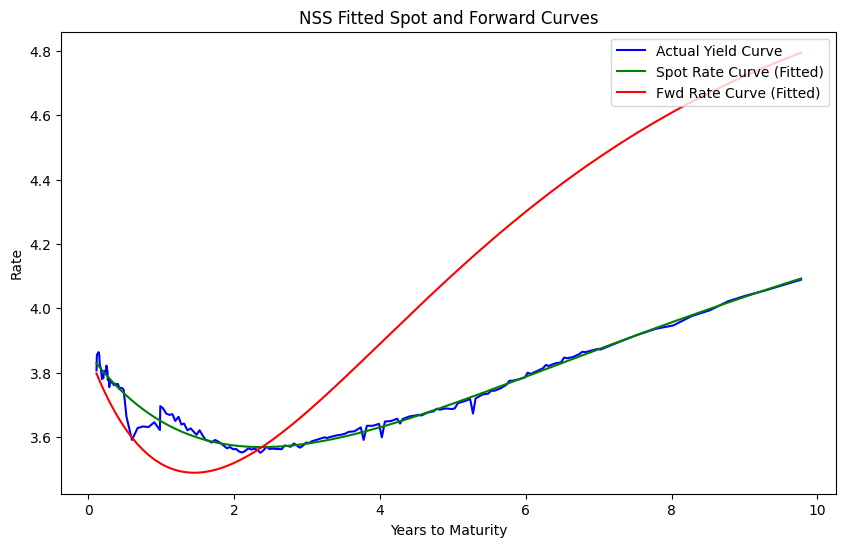

In [11]:
#Fit NSS Curve to this
yc = pd.read_excel(r'''QLED.xlsx''',
            sheet_name='YieldCurve')

#NSS functions
def NssSpot(maturity,coeffs):
    test = (coeffs[0] + coeffs[1]*((1-np.exp(-maturity/coeffs[4]))/(maturity/coeffs[4])) + coeffs[2]*(((1-np.exp(-maturity/coeffs[4]))/(maturity/coeffs[4]))-(np.exp(-maturity/coeffs[4])))
    + coeffs[3]*(((1-np.exp(-maturity/coeffs[5]))/(maturity/coeffs[5]))-(np.exp(-maturity/coeffs[5]))))
    return test

def NssFwd(maturity,coeffs):
    test = (coeffs[0] + coeffs[1]*((np.exp(-maturity/coeffs[4]))) + coeffs[2]*(maturity/coeffs[4])*(np.exp(-maturity/coeffs[4]))
    + coeffs[3]*(maturity/coeffs[5])*(np.exp(-maturity/coeffs[5])))
    return test
    
    
def Tenor(start,maturity):
     num = (360 * (maturity.year - start.year) + (30*(maturity.month - start.month) + (maturity.day - start.day)))
     return num / 360


yc['Tenor'] = np.nan
yc.reset_index()
for x in yc.index:
    yc['Tenor'][x] = Tenor(yc['Date'][x],yc['Maturity'][x])

def NssFitSpot(coeffs):
    my = yc[['Tenor','Yield']]
    test = (coeffs[0] + coeffs[1]*((1-np.exp(-my.iloc[:,0]/coeffs[4]))/(my.iloc[:,0]/coeffs[4])) + coeffs[2]*(((1-np.exp(-my.iloc[:,0]/coeffs[4]))/(my.iloc[:,0]/coeffs[4]))-(np.exp(-my.iloc[:,0]/coeffs[4])))
    + coeffs[3]*(((1-np.exp(-my.iloc[:,0]/coeffs[5]))/(my.iloc[:,0]/coeffs[5]))-(np.exp(-my.iloc[:,0]/coeffs[5])))) - my.iloc[:,1]
    sumresid = (test.apply(lambda num:num*num)).sum()
    return sumresid

fit = scipy.optimize.fmin_bfgs(NssFitSpot,[3,1,-3,5,1,20])
yc['SpotCurve'] = NssSpot(yc['Tenor'],fit)
yc['ForwardCurve'] = NssFwd(yc['Tenor'],fit)
fig, ax1 = mpl.subplots(figsize=(10, 6))
ax1.plot(yc['Tenor'],yc['Yield'], color='b',label = 'Actual Yield Curve')
ax1.plot(yc['Tenor'],yc['SpotCurve'], color='g',label = 'Spot Rate Curve (Fitted)')
ax1.plot(yc['Tenor'],yc['ForwardCurve'], color='r',label = 'Fwd Rate Curve (Fitted)')
ax1.legend(loc='upper right')
ax1.set_xlabel('Years to Maturity')
ax1.set_ylabel('Rate')
ax1.set_title('NSS Fitted Spot and Forward Curves')

# Using the NSS spot rate curve, QuantLib offers a convenient way to run Hull-White Simulations
* We get the zero curve/spot curve from NSS
* Convert Maturities to QuantLib date format
* Set Hull White inputs: alpha = mean reversion, sigma = volatility
    * alpha = .000001, minimal mean reversion
    * sigma = 10%, which is low for what we have seen recently
* Our simulation will go out 9 years
* QuantLib has a built in random number generator (Gaussian) that we will utilize


In [12]:
#Tenor to Maturity
YieldCurve = pd.DataFrame()
YieldCurve['Maturity'] = yc['Maturity']
YieldCurve['Yield'] = NssSpot(yc['Tenor'],fit)
for x in YieldCurve.index:
    YieldCurve['Maturity'][x] = ql.Date(YieldCurve['Maturity'][x].day,YieldCurve['Maturity'][x].month,YieldCurve['Maturity'][x].year)

ql.Settings.instance().evaluationDate = ql.Date(11,6,2025)
zc = ql.ZeroCurve((YieldCurve['Maturity']),(YieldCurve['Yield']),ql.Actual365Fixed())
riskFreeTS = ql.YieldTermStructureHandle(zc)
a = 0.000001
sigma = 0.10
timestep = 120
length = 9 # in years
process = ql.HullWhiteProcess(riskFreeTS, a, sigma)
rng = ql.GaussianRandomSequenceGenerator(ql.UniformRandomSequenceGenerator(timestep, ql.UniformRandomGenerator()))
seq = ql.GaussianPathGenerator(process, length, timestep, rng, False)
def generate_paths(num_paths, timestep):
    arr = np.zeros((num_paths, timestep+1))
    for i in range(num_paths):
        sample_path = seq.next()
        path = sample_path.value()
        time = [path.time(j) for j in range(len(path))]
        value = [path[j] for j in range(len(path))]
        arr[i, :] = np.array(value)
    return np.array(time), arr

# Paths have been generated
* Next we chart the output
* You can see the paths roughly approximate the yield curve structure
* Higher volatility could make sense here
* Rates do not go negative given the starting point

Text(0.5, 1.0, 'Hull-White Short Rate Simulation')

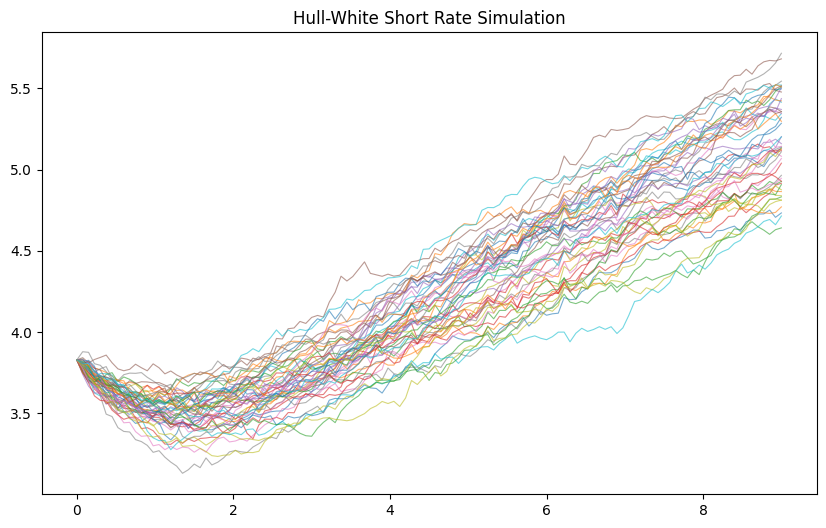

In [13]:
fig1, ax2 = mpl.subplots(figsize=(10, 6))
num_paths = 50
time, paths = generate_paths(num_paths, timestep)
for i in range(num_paths):
    ax2.plot(time, paths[i, :], lw=0.8, alpha=0.6)
ax2.set_title("Hull-White Short Rate Simulation")

# What Happens if we input todays rate only?
* No term structure added, just an assumption of 3.875% rate right now
* Chart shows that rates do not necessarily fall as the forward rate implies currently
* Gives an alternative to assuming the market is correct, which would have been useful in recent years
* In a practical sense, you cannot price bonds without considering the term structure
* However, this may give an unbiased/more random view on future rates

Text(0.5, 1.0, 'Hull-White Short Rate Simulation')

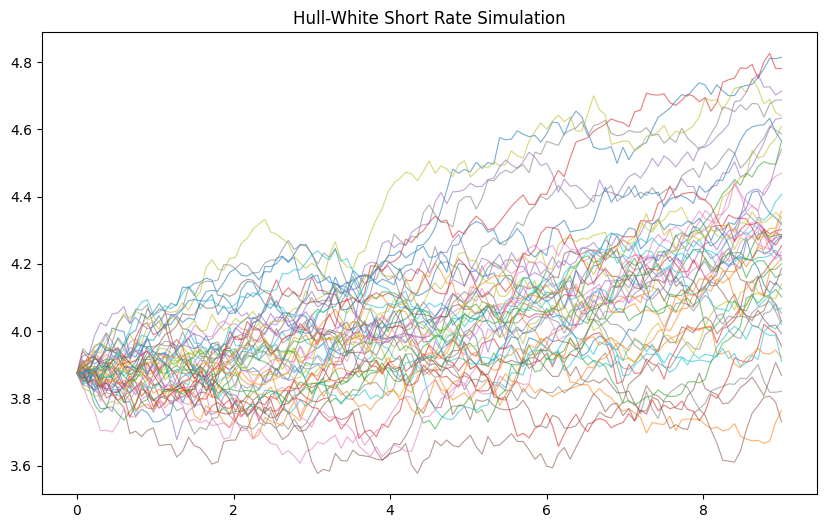

In [14]:
ql.Settings.instance().evaluationDate = ql.Date(11,6,2025)
zc = ql.FlatForward(ql.Date(11,6,2025), ql.QuoteHandle(ql.SimpleQuote(3.875)), ql.Actual365Fixed())
riskFreeTS = ql.YieldTermStructureHandle(zc)
a = 0.000001
sigma = 0.1
timestep = 120
length = 9 # in years
process = ql.HullWhiteProcess(riskFreeTS, a, sigma)
rng = ql.GaussianRandomSequenceGenerator(ql.UniformRandomSequenceGenerator(timestep, ql.UniformRandomGenerator()))
seq = ql.GaussianPathGenerator(process, length, timestep, rng, False)
def generate_paths(num_paths, timestep):
    arr = np.zeros((num_paths, timestep+1))
    for i in range(num_paths):
        sample_path = seq.next()
        path = sample_path.value()
        time = [path.time(j) for j in range(len(path))]
        value = [path[j] for j in range(len(path))]
        arr[i, :] = np.array(value)
    return np.array(time), arr


fig1, ax2 = mpl.subplots(figsize=(10, 6))
num_paths = 50
time, paths = generate_paths(num_paths, timestep)
for i in range(num_paths):
    ax2.plot(time, paths[i, :], lw=0.8, alpha=0.6)
ax2.set_title("Hull-White Short Rate Simulation")